In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import torch

In [ ]:
!pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
from kan import KAN
import torch.nn as nn

In [ ]:
data = load_breast_cancer(as_frame=True)

In [ ]:
type(data.data)

pandas.core.frame.DataFrame

In [ ]:
x, y = data.data, data.target

In [ ]:
x = (x - x.mean()) / x.std()


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:
train_input = torch.from_numpy(x_train.values).float()
train_label = torch.from_numpy(y_train.values).long()
test_input  = torch.from_numpy(x_test.values).float()
test_label  = torch.from_numpy(y_test.values).long()


In [ ]:
dataset = {'train_input': train_input, 'train_label': train_label,'test_input': test_input, 'test_label': test_label}

In [ ]:
width = [30, 5, 5, 2]

In [ ]:
def seed_all(self, seed):
    numpy.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:
model = KAN(width=width, grid=1, k=1, seed=0, sparse_init=True)

checkpoint directory created: ./model
saving model version 0.0


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.get_params(), lr=0.001)

In [ ]:
lamb = 0.001
old_save_act, old_symbolic_enabled = model.disable_symbolic_in_fit(lamb)

In [ ]:
best_loss = float('inf')
patience_counter = 0
patience = 30
steps = 10000
stop_grid_update_step = 50
grid_update_freq = stop_grid_update_step // 10

In [ ]:
for step in range(steps):

    if step % grid_update_freq == 0 and step < stop_grid_update_step:
      model.update_grid(dataset['train_input'])


    pred_train = model.forward(dataset['train_input'])
    train_loss = criterion(pred_train, dataset['train_label'])


    reg = model.get_reg('edge_forward_spline_n', 1.0, 0.1, 0.0, 0.0)
    loss = train_loss + lamb * reg

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



    with torch.no_grad():
        pred_test = model.forward(dataset['test_input'])
        test_loss = criterion(pred_test, dataset['test_label'])

    if test_loss.item() < best_loss:
        best_loss = test_loss.item()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter > patience:
            print(step)
            break

112


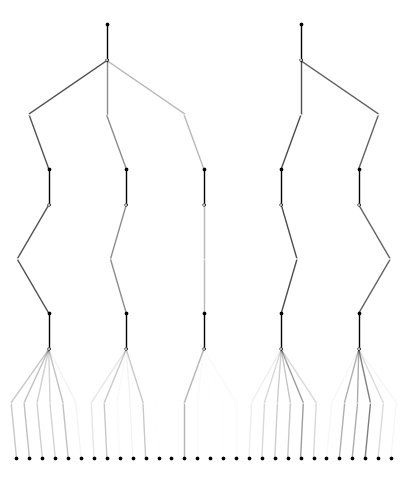

In [ ]:
model.plot()

In [ ]:
model = model.prune()

saving model version 0.1


In [ ]:
sm = nn.Softmax(dim=1)
proba = sm(model.forward(dataset['test_input'])).detach().numpy()
preds = proba.argmax(axis=1)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(test_label.numpy(), preds))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        47
           1       0.97      1.00      0.99        67

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
from sklearn.metrics import recall_score
recall_score(test_label.numpy(), preds, zero_division=0)

1.0

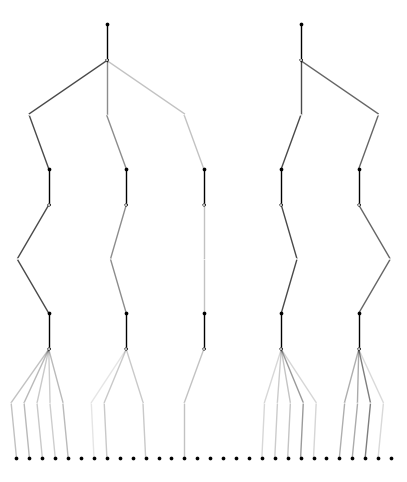

In [ ]:
model.plot()

In [ ]:
model.auto_symbolic()

fixing (0,0,0) with sin, r2=0.9999045729637146, c=2
fixing (0,0,1) with 0
fixing (0,0,2) with 0
fixing (0,0,3) with 0
fixing (0,0,4) with 0
fixing (0,1,0) with 0, r2=0.0, c=0
fixing (0,1,1) with 0
fixing (0,1,2) with 0
fixing (0,1,3) with 0
fixing (0,1,4) with 0
fixing (0,2,0) with sin, r2=0.9998311996459961, c=2
fixing (0,2,1) with 0
fixing (0,2,2) with 0
fixing (0,2,3) with 0
fixing (0,2,4) with 0
fixing (0,3,0) with cos, r2=0.9999727010726929, c=2
fixing (0,3,1) with 0
fixing (0,3,2) with 0
fixing (0,3,3) with 0
fixing (0,3,4) with 0
fixing (0,4,0) with x, r2=0.9892145991325378, c=1
fixing (0,4,1) with 0
fixing (0,4,2) with 0
fixing (0,4,3) with 0
fixing (0,4,4) with 0
fixing (0,5,0) with 0
fixing (0,5,1) with 0
fixing (0,5,2) with 0
fixing (0,5,3) with 0
fixing (0,5,4) with 0
fixing (0,6,0) with 0
fixing (0,6,1) with sin, r2=0.9999385476112366, c=2
fixing (0,6,2) with 0
fixing (0,6,3) with 0
fixing (0,6,4) with 0
fixing (0,7,0) with 0
fixing (0,7,1) with cos, r2=0.9998955726623535,

In [ ]:
model.symbolic_formula(None, )

/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


([-2.20022203562872*exp(-0.085761749722514*x_5 - 0.604260447631727*sin(0.220159992575645*x_1 - 0.929279863834381) - 0.425594944275041*sin(0.273999959230423*x_3 - 7.25663995742798) - 0.350576853060783*cos(0.254239976406097*x_4 - 2.29295969009399)) - 3.4411256313324*sin(1.1682328501222*cos(0.253572228826926*sin(0.376959830522537*x_7 + 2.18279981613159) - 0.560950008797477*cos(0.473199844360352*x_11 - 8.96695995330811) + 0.550900976376056*cos(0.44191986322403*x_8 - 5.77511978149414) + 4.40605320876483) - 6.15827008313395) + 9.72097326589966,
  8.18835759162903 - 2.18461680412292*Abs(0.114135913892941*(-0.816511047126454*sin(0.354799836874008*x_20 - 4.36183977127075) + 1.18166493579366*sin(0.389919847249985*x_21 + 8.37639999389648) + 2.24347497252836*sin(0.377519845962524*x_23 + 2.1690399646759) - 0.815807425007563*sin(0.449519842863083*x_24 + 5.23559999465942) + 1.37130353312011*cos(0.336559861898422*x_22 - 5.66447973251343) + 1.72300838786904)**2 - 6.75268370404945)],
 [x_1,
  x_2,
  x_3